# Tiny NeRF

Simplified NeRF without 5D input including view direction
Hierarchical sampling

In [ ]:
#TODO
# Random ray_o and ray_d sampling to run 128 samples
# Extend to Original NeRF with 5D input and hierarchical sampling

In [ ]:
!nvidia-smi

In [3]:
import os, sys
import torch
import torch.nn as nn

import time
import numpy as np
import matplotlib.pyplot as plt
import time

import viser
import viser.transforms as tf



In [4]:
# !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

In [5]:
#Load Dataset
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal =  np.float32(data['focal'])


print(images.shape, poses.shape, focal)
H, W = images.shape[1:3]


(106, 100, 100, 3) (106, 4, 4) 138.88889


In [6]:
train_images, train_poses = torch.tensor(images[:100], dtype=torch.float32), torch.tensor(poses[:100],  dtype=torch.float32) 
test_images, test_poses = torch.tensor(images[100:], dtype=torch.float32), torch.tensor(poses[100:],  dtype=torch.float32) 

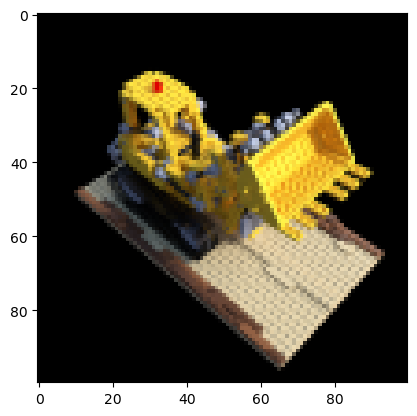

tensor([[ 6.8935e-01,  5.3373e-01, -4.8982e-01, -1.9745e+00],
        [-7.2443e-01,  5.0789e-01, -4.6611e-01, -1.8789e+00],
        [ 1.4901e-08,  6.7615e-01,  7.3676e-01,  2.9700e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])


In [7]:
plt.imshow(test_images[1])
plt.show()
print(test_poses[1])

In [8]:
#Model Class
class NeRF(nn.Module):
    def __init__(self, L_embed=6, D=8 , W=256):
        super().__init__()

        input_ch = 3 + 3 * 2 * L_embed
    
        self.layers = nn.ModuleList()
        in_ch = input_ch
        for i in range(D):
            self.layers.append(nn.Linear(in_ch, W))
            in_ch = W + input_ch  if (i % 4 == 0 and i > 0) else W
        self.output_layer = nn.Linear(in_ch, 4)

    
    def forward(self, x):
        inputs = x
        for i, layer in enumerate(self.layers):
            x = torch.relu(layer(x))
            if i % 4 ==0 and i > 0: 
                x = torch.concat([x, inputs], dim=-1)
        return self.output_layer(x)
    


In [9]:
print(torch.cuda.is_available())
device = torch.device('cuda')

model = NeRF().to(device)

True


In [10]:
model.load_state_dict(torch.load('model_64_10000.pth'))

<All keys matched successfully>

## Ray Generation

Each pixel $(i, j)$ maps to a ray with origin $\mathbf{o}$ and direction $\mathbf{d}$:

$$\mathbf{d}_{ij} = R \cdot \begin{pmatrix} (i - W/2) / f \\\\ -(j - H/2) / f \\\\ -1 \end{pmatrix}$$

$$\mathbf{o} = \mathbf{t}_{cam} \quad \text{(camera translation from c2w)}$$

where $f$ is the focal length and $R$ is the $3 \times 3$ rotation from the camera-to-world matrix.

In [11]:
#Generate ray origin and direction
def get_rays(H, W, focal, c2w, device='cpu'):
    c2w = c2w.to(device)
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=device), torch.arange(H, dtype= torch.float32, device=device), indexing='xy')
    dirs = torch.stack([(i - W*0.5)/focal, -(j -H*0.5)/focal, -torch.ones_like(i)], dim=-1)

    rays_d = dirs @ c2w[:3,:3].T
    rays_o = c2w[:3, -1].expand(rays_d.shape)

    return rays_o, rays_d


## Positional Encoding

Raw 3D coordinates are lifted to a higher-dimensional space so the MLP can represent high-frequency detail:

$$\gamma(p) = \left( p,\ \sin(2^0 p),\ \cos(2^0 p),\ \ldots,\ \sin(2^{L-1} p),\ \cos(2^{L-1} p) \right)$$

With $L=6$ and input dim $3$: output dim $= 3 + 2 \times 6 \times 3 = 39$.

In [12]:
#Generate position embedding
def embed_fn(x, L_embed=6):
  rets = [x]
  for i in range(L_embed):
    for fn in [torch.sin, torch.cos]:
      rets.append(fn(2.**i * x))
  return torch.concat(rets, -1)

## Volume Rendering

**Sample points along ray:**
$$\mathbf{x}_i = \mathbf{o} + t_i\,\mathbf{d}, \quad t_i \in [t_{near}, t_{far}]$$

**Distance between samples:**
$$\delta_i = t_{i+1} - t_i \quad (\delta_N = \infty)$$

**Alpha (opacity) at each sample:**
$$\alpha_i = 1 - \exp(-\sigma_i \cdot \delta_i)$$

**Transmittance — probability light reaches point $i$ unobstructed:**
$$T_i = \prod_{j < i}(1 - \alpha_j)$$

**Per-sample weight:**
$$w_i = T_i \cdot \alpha_i$$

**Final pixel outputs:**
$$C(\mathbf{r}) = \sum_i w_i \cdot \mathbf{c}_i \qquad \text{(RGB map)}$$
$$D(\mathbf{r}) = \sum_i w_i \cdot t_i \qquad \text{(Depth map)}$$
$$A(\mathbf{r}) = \sum_i w_i \qquad \text{(Accumulation / opacity mask)}$$

In [13]:
#Render depth along the ray direction
def render_rays(model, rays_o, rays_d, near, far, N_samples, chunk=1024*32, rand=False):

   z_vals = torch.linspace(near, far, N_samples, device=rays_o.device) #Compute 3D query points
   if rand:
      z_vals = z_vals + torch.rand(list(rays_o.shape[:-1]) + [N_samples], device=rays_o.device) * (far - near)/ N_samples
   pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., None]

   # Run network
   pts_flat = pts.view(-1, 3)
   pts_flat = embed_fn(pts_flat)

   # raw = torch.cat([model(pts_flat[i: i+chunk]) for i in range(0, pts_flat.shape[0], chunk)], dim=0)
   raw = torch.zeros(pts_flat.shape[0], 4, device=rays_o.device)
   for i in range(0, pts_flat.shape[0], chunk):
      raw[i: i+chunk] = model(pts_flat[i: i+chunk])

   del pts_flat

   raw = raw.reshape(pts.shape[:-1] + (4,))
   # Compute opacities and colors
   sigma_a  = torch.relu(raw[..., 3])
   rgb      = torch.sigmoid(raw[...,:3])

   # Do volume rendering 
   dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.ones_like(z_vals[..., :1]) * 1e10], -1)
   alpha = 1.0 - torch.exp(-sigma_a * dists)
   T = torch.cumprod(1.0 - alpha + 1e-10, -1)
   weights = alpha * torch.cat([torch.ones_like(T[..., :1]), T[..., :-1]], dim=-1)

   rgb_map = torch.sum(weights[..., None] * rgb, dim = -2)
   depth_map = torch.sum(weights * z_vals, dim=-1)
   acc_map = torch.sum(weights, dim=-1)
   return rgb_map, depth_map, acc_map

## Training & Evaluation

**Loss** — Mean Squared Error on rendered vs ground truth RGB:
$$\mathcal{L} = \frac{1}{|\mathcal{R}|} \sum_{\mathbf{r} \in \mathcal{R}} \| C(\mathbf{r}) - C_{gt}(\mathbf{r}) \|_2^2$$

**PSNR** (Peak Signal-to-Noise Ratio):
$$\text{PSNR} = -10 \cdot \log_{10}(\text{MSE})$$

Higher PSNR = better quality. TinyNeRF targets **25–28 dB** after ~10,000 iterations.

In [14]:
N_samples = 64
N_iters = 10000
psnrs = []
iternums = []
i_plot = 25
chunk = 1024*32

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()

train = False

if train:
    t = time.time()
    model.train()
    for i in range(N_iters+1):
        img_i   = np.random.randint(train_images.shape[0])
        target  = train_images[img_i].to(device)
        pose    = train_poses[img_i].to(device)
        ray_o, ray_d = get_rays(H, W, focal, pose, device)
        

        optimizer.zero_grad()
        rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0, N_samples=N_samples, chunk=chunk, rand=True)
        loss = criterion(rgb, target)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"iter {i}, loss: {loss.item():.4f}")

        if i % i_plot == 0: 
            print(i, (time.time() - t) / i_plot, "secs per iter")
            t = time.time()

            with torch.no_grad():
                current_psnr = 0.0
                iternums.append(i)
                num_test_images = test_images.shape[0]
                rand_test_disp = np.random.randint(num_test_images)
                for test_img_i in range(num_test_images):
                    test_target  = test_images[test_img_i].to(device)
                    test_pose    = test_poses[test_img_i].to(device)
                    ray_o, ray_d = get_rays(H, W, focal, test_pose, device)
                    rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0, N_samples=N_samples, chunk=chunk, rand=False)
                    loss = criterion(rgb, test_target)
                    current_psnr += -10. * torch.log10(loss).item()
                    if test_img_i == rand_test_disp:
                        rgb_disp = rgb.cpu()
                        depth_disp = depth.cpu()
                    del ray_o, ray_d, rgb, depth, acc, loss
                torch.cuda.empty_cache()


                    
                psnrs.append(current_psnr/ num_test_images)
                plt.figure(figsize=(10,4))
                plt.subplot(121)
                plt.imshow(rgb_disp.numpy())
                plt.title(f'Rendered: {i}')

                # plt.subplot(142)
                # plt.imshow(test_images[rand_test_disp].numpy())
                # plt.title('Ground Truth')

                # plt.subplot(143)
                # plt.imshow(depth_disp.cpu().detach().numpy(), cmap='inferno')
                # plt.title('Depth')
                # plt.colorbar()

                plt.subplot(122)
                plt.plot(iternums, psnrs)
                plt.title('PSNR')
                plt.show()
        

In [15]:
# torch.save(model.state_dict(), 'model_64_fine_tuned_10000.pth')

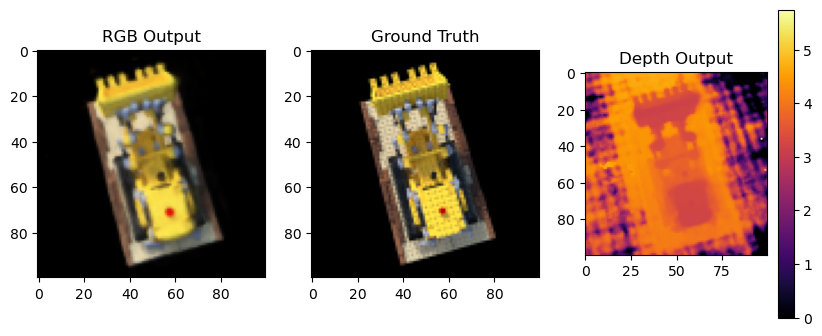

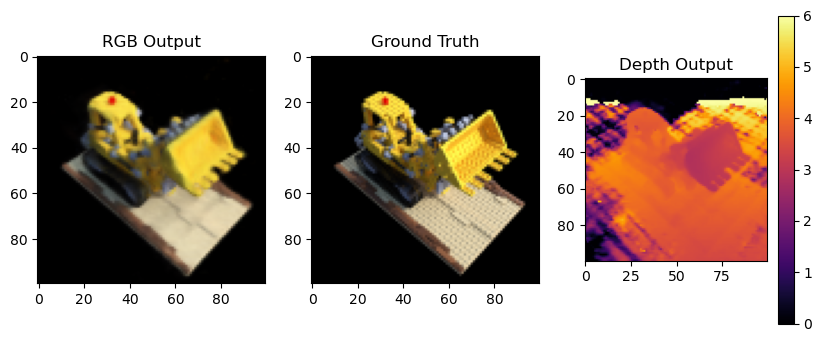

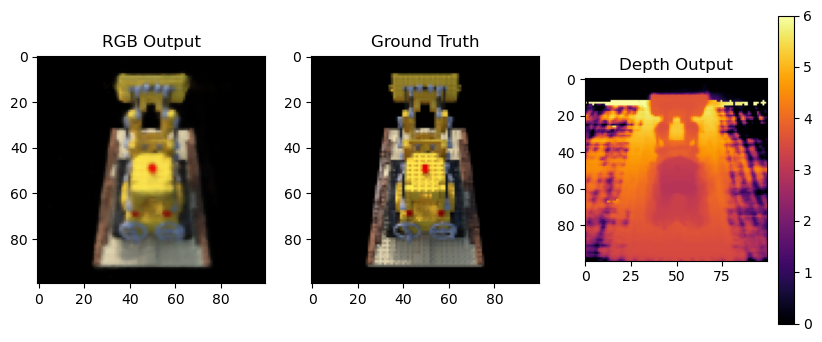

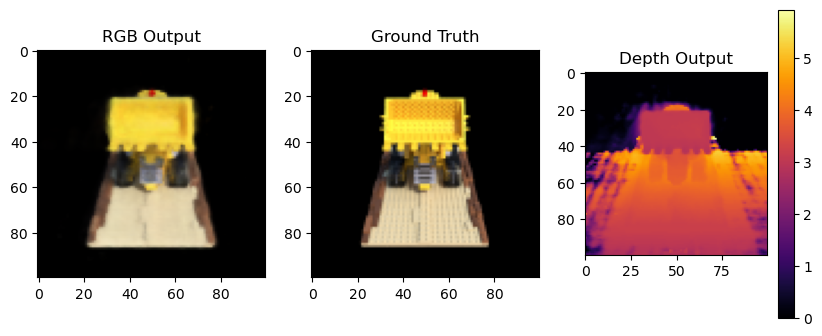

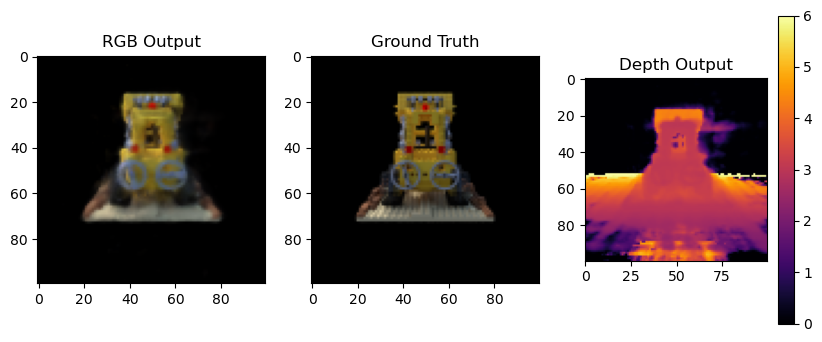

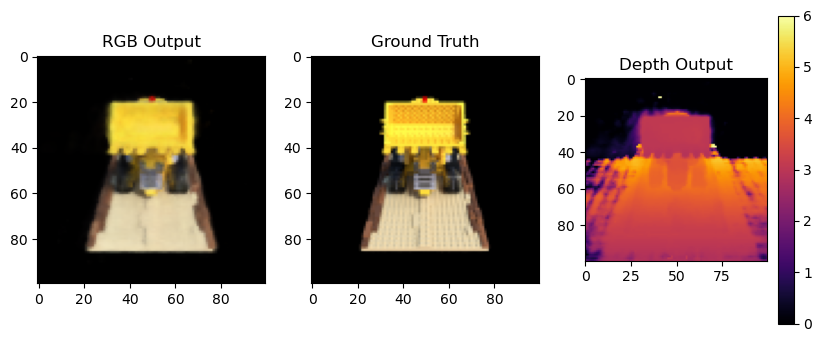

In [16]:
model.eval()
with torch.no_grad():  
    num_test_images = test_images.shape[0]
    for test_img_i in range(num_test_images):
        test_target  = test_images[test_img_i]
        test_pose    = test_poses[test_img_i].to(device)
        ray_o, ray_d = get_rays(H, W, focal, test_pose, device)
        rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0, N_samples=N_samples, rand=False)
        plt.figure(figsize=(10,4))
        plt.subplot(131)
        plt.imshow(rgb.cpu().detach().numpy())
        plt.title('RGB Output')

        plt.subplot(132)
        plt.imshow(test_target)
        plt.title('Ground Truth')

        plt.subplot(133)
        plt.imshow(depth.cpu().detach().numpy(), cmap='inferno')
        plt.title('Depth Output')
        plt.colorbar()

        plt.show()

In [ ]:
#Viser to render all training poses and 1 test point cloud

server = viser.ViserServer(host="0.0.0.0", port=8080)

# 1. Show all training camera poses as frustums
for i, pose in enumerate(train_poses):
    pose_np = pose.numpy()
    server.scene.add_camera_frustum(
        f"/cameras/train_{i}",
        fov=float(2 * np.arctan(W / (2 * focal))),
        aspect=W / H,
        scale=0.1,
        wxyz= (tf.SO3.from_matrix(pose_np[:3, :3]) @  tf.SO3.from_x_radians(np.pi)).wxyz,
        position=pose_np[:3, 3],
        color=(0, 120, 255),
    )

# 2. Render one test image and show as point cloud using depth
model.eval()
with torch.no_grad():
    pose = test_poses[0].to(device)
    ray_o, ray_d = get_rays(H, W, focal, pose, device)
    rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0, N_samples=64, chunk=1024*32, rand=False)

    # Compute 3D point positions from depth
    pts3d = ray_o + ray_d * depth[..., None]  # [H, W, 3]

    pts3d_np = pts3d.cpu().numpy().reshape(-1, 3)
    rgb_np   = (rgb.cpu().numpy().reshape(-1, 3) * 255).astype(np.uint8)
    acc_np   = acc.cpu().numpy().reshape(-1)

    # Only show points with high accumulation (actual geometry)
    mask = acc_np > 0.8
    server.scene.add_point_cloud(
        "/nerf/pointcloud",
        points=pts3d_np[mask],
        colors=rgb_np[mask],
        point_size=0.02,
    )


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

Open http://localhost:8080 in your browser


(viser) Connection opened (0, 1 total), 411 persistent messages

In [ ]:
server.stop()

In [ ]:
#Press button to render novel view
server = viser.ViserServer(host="0.0.0.0", port=8080)

with torch.no_grad():
    pose = test_poses[0].to(device)
    ray_o, ray_d = get_rays(H, W, focal, pose, device)
    rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0, N_samples=64, chunk=1024*32, rand=False)

    # Compute 3D point positions from depth
    pts3d = ray_o + ray_d * depth[..., None]  # [H, W, 3]

    pts3d_np = pts3d.cpu().numpy().reshape(-1, 3)
    rgb_np   = (rgb.cpu().numpy().reshape(-1, 3) * 255).astype(np.uint8)
    acc_np   = acc.cpu().numpy().reshape(-1)

    # Only show points with high accumulation (actual geometry)
    mask = acc_np > 0.8
    server.scene.add_point_cloud(
        "/nerf/pointcloud",
        points=pts3d_np[mask],
        colors=rgb_np[mask],
        point_size=0.02,
    )

render_btn = server.gui.add_button("Render Novel View")

@render_btn.on_click
def render_novel_view(_):
    clients = server.get_clients()
    if not clients:
        print("No client connected")
        return

    client = list(clients.values())[0]

    R = (tf.SO3(client.camera.wxyz) @ tf.SO3.from_x_radians(np.pi)).as_matrix()
    t = np.array(client.camera.position)

    # Show viewing camera as frustum
    server.scene.add_camera_frustum(
        "/nerf/render_camera",
        fov=float(2 * np.arctan(W / (2 * focal))),
        aspect=W / H,
        scale=0.15,
        wxyz=client.camera.wxyz,
        position=t,
        color=(255, 80, 0),  # orange to distinguish from blue train cameras
    )

    c2w = np.eye(4)
    c2w[:3, :3] = R
    c2w[:3,  3] = t
    c2w_tensor = torch.tensor(c2w, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        ray_o, ray_d = get_rays(H, W, focal, c2w_tensor, device)
        rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0,
                                       N_samples=64, chunk=1024*32, rand=False)

    # Build point cloud from depth
    pts3d    = ray_o + ray_d * depth[..., None]
    pts3d_np = pts3d.cpu().numpy().reshape(-1, 3)
    rgb_np   = (rgb.cpu().numpy().reshape(-1, 3) * 255).astype(np.uint8)
    acc_np   = acc.cpu().numpy().reshape(-1)
    mask     = acc_np > 0.8

    server.scene.add_point_cloud(
        "/nerf/pointcloud",
        points=pts3d_np[mask],
        colors=rgb_np[mask],
        point_size=0.02,
    )
    print(f"Rendered {mask.sum()} points from {t.round(2)}")

print("Navigate and click 'Render Novel View'")


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

Navigate and click 'Render Novel View'


(viser) Connection opened (0, 1 total), 10 persistent messages

Rendered 4918 points from [4.71 0.5  2.14]
Rendered 4809 points from [4.52 0.24 2.56]
Rendered 4885 points from [ 1.73 -3.55  3.38]
Rendered 4596 points from [ 1.84 -3.77  3.59]
Rendered 4089 points from [ 3.49 -0.57  4.24]
Rendered 3608 points from [0.93 2.16 4.99]


In [ ]:
#Drag and render novel view
import threading
server = viser.ViserServer(host="0.0.0.0", port=8080)

def render_from_client(client):
    R = (tf.SO3(client.camera.wxyz) @ tf.SO3.from_x_radians(np.pi)).as_matrix()
    t = np.array(client.camera.position)

    server.scene.add_camera_frustum(
        "/nerf/render_camera",
        fov=float(2 * np.arctan(W / (2 * focal))),
        aspect=W / H,
        scale=0.15,
        wxyz=client.camera.wxyz,
        position=t,
        color=(255, 80, 0),
    )

    c2w = np.eye(4)
    c2w[:3, :3] = R
    c2w[:3,  3] = t
    c2w_tensor = torch.tensor(c2w, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        ray_o, ray_d = get_rays(H, W, focal, c2w_tensor, device)
        rgb, depth, acc = render_rays(model, ray_o, ray_d, near=2.0, far=6.0,
                                       N_samples=64, chunk=1024*32, rand=False)

    pts3d    = ray_o + ray_d * depth[..., None]
    pts3d_np = pts3d.cpu().numpy().reshape(-1, 3)
    rgb_np   = (rgb.cpu().numpy().reshape(-1, 3) * 255).astype(np.uint8)
    mask     = acc.cpu().numpy().reshape(-1) > 0.8

    server.scene.add_point_cloud(
        "/nerf/pointcloud",
        points=pts3d_np[mask],
        colors=rgb_np[mask],
        point_size=0.02,
    )

@server.on_client_connect
def on_connect(client):
    timer = [None]  # use list to allow mutation inside closure

    @client.camera.on_update
    def on_camera_update(cam):
        if timer[0]:
            timer[0].cancel()
        timer[0] = threading.Timer(0.3, lambda: render_from_client(client))
        timer[0].start()

print("Navigate to render novel view'")


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 5 persistent messages

In [21]:
server.stop()

(viser) Connection closed (0, 0 total)

(viser) Server stopped

Code inspired from Orignal TinyNeRF implementation (https://github.com/bmild/nerf) and vizer visualization generated using ClaudeCode